# Part 2 – Named Entity Recognition (NER) using a Feed-Forward Neural Network

---


### Pipeline Overview

```
Raw token  →  lowercase  →  word2idx lookup  →  embeddings[idx]  →  FFNN  →  NER tag
  "EU"     →    "eu"     →       42          →  [0.3, -0.1, ...]  →       →   B-ORG
```
**Step 1 — Linear Layer:**

Each linear layer applies a simple transformation:

$$\mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}$$

Where:
- $\mathbf{x}$ → input vector
- $\mathbf{W}$ → weight matrix (learned)
- $\mathbf{b}$ → bias vector (learned)
- $\mathbf{z}$ → output (raw scores)

**Step 2 — ReLU Activation:**

$$\text{ReLU}(z_i) = \max(0,\ z_i)$$

Negative values are zeroed out. This introduces non-linearity — without it,
stacking multiple linear layers would still just be one linear transformation
and the model could only learn straight-line decision boundaries.

**Step 3 — Output Layer:**

The final linear layer outputs 9 raw scores (one per NER tag) called **logits**:

$$\mathbf{\hat{y}} = \mathbf{W_3} \mathbf{h_2} + \mathbf{b_3} \in \mathbb{R}^9$$

The tag with the highest logit is the prediction:

$$\hat{\text{tag}} = \arg\max_i\ \hat{y}_i$$

---

### Loss Function — Cross Entropy

Cross Entropy measures how wrong the predicted logits are compared to the true tag.
It first converts logits to probabilities using **Softmax**:

$$P(\text{tag} = i \mid \mathbf{x}) = \frac{e^{\hat{y}_i}}{\sum_{j=1}^{9} e^{\hat{y}_j}}$$

Then computes the negative log probability of the correct tag $c$:

$$\mathcal{L} = -\log P(\text{tag} = c \mid \mathbf{x})$$

- If the model is **confident and correct** → $P$ close to 1 → $\mathcal{L}$ close to 0
- If the model is **wrong or uncertain** → $P$ is small → $\mathcal{L}$ is large

---

### Backpropagation

Backpropagation computes how much each weight $\mathbf{W}$ contributed to the loss,
using the **chain rule** of calculus — working backwards from the loss to the input.

For a weight $w$ in any layer:

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w}$$

Each term is:

| Term | Meaning |
|---|---|
| $\frac{\partial \mathcal{L}}{\partial \hat{y}}$ | How much the loss changes when the output changes |
| $\frac{\partial \hat{y}}{\partial z}$ | How much the output changes when the pre-activation changes (ReLU gradient: 1 if $z>0$, else 0) |
| $\frac{\partial z}{\partial w}$ | How much the pre-activation changes when the weight changes (equals $x$) |

So the full gradient for a weight in layer 1 is a **chain** of gradients multiplied together
all the way from the loss back to that layer.

---

### Weight Update — Gradient Descent

Once we have the gradient, Adam uses it to update every weight:

$$w \leftarrow w - \alpha \cdot \frac{\partial \mathcal{L}}{\partial w}$$

Where $\alpha = 0.001$ is the learning rate. A smaller gradient → smaller update.
A larger gradient → larger update. Over many batches and epochs, this pushes
the weights toward values that minimise the loss.

---

### Full Picture Per Batch

$$\underbrace{\mathbf{x}}_{\text{500-dim input}} \xrightarrow{\text{forward}} \underbrace{\hat{\mathbf{y}}}_{\text{9 logits}} \xrightarrow{\text{loss}} \underbrace{\mathcal{L}}_{\text{scalar}} \xrightarrow{\text{backward}} \underbrace{\nabla \mathbf{W}}_{\text{gradients}} \xrightarrow{\text{Adam}} \underbrace{\mathbf{W}'}_{\text{updated weights}}$$

---
## Step 1 — Load the Pre-trained Embeddings

We saved three things at the end of Part 1:

| File | Contents |
|---|---|
| `embeddings.pt` | The trained embedding matrix — shape `(12113, 100)` |
| `word2idx.pkl` | Dict mapping every word → its row index in the matrix |
| `idx2word.pkl` | Dict mapping every index → its word (reverse lookup) |

We use the custom `load_embeddings_and_vocab` function from `load.py` to bring all three back into memory.

In [1]:
import sys
sys.path.append("../../Word2vec")

from load import load_embeddings_and_vocab

embeddings, word2idx, idx2word = load_embeddings_and_vocab(
    emb_path      = "../../Word2vec/embeddings.pt",
    word2idx_path = "../../Word2vec/word2idx.pkl",
    idx2word_path = "../../Word2vec/idx2word.pkl"
)

# Convert to numpy for the NER model
embeddings = embeddings.numpy()

print(f"Embeddings shape : {embeddings.shape}")
print(f"Vocab size       : {len(word2idx)}")

Embeddings shape : (12113, 100)
Vocab size       : 12113


## Imports

In [2]:
%pip install datasets

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import pandas as pd
from sklearn.metrics import (
    f1_score, accuracy_score,
    precision_score, recall_score,
    classification_report
)
import matplotlib.pyplot as plt

dataset = load_dataset("lhoestq/conll2003")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Note: you may need to restart the kernel to use updated packages.
Using: cpu


## Preparing Labels---
## Step 3 — Prepare NER Labels

CoNLL-2003 uses the **BIO tagging scheme**:
- **B** = Beginning of an entity
- **I** = Inside an entity (continuation)
- **O** = Outside (not an entity)

There are 4 entity types: `PER` (person), `ORG` (organisation), `LOC` (location), `MISC` (miscellaneous)  
→ giving **9 tags** total.

The dataset stores tags as integers (0–8). We build two lookup dicts so we can convert between the integer and the human-readable label in both directions.

In [3]:
label_names = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
label2idx   = {l: i for i, l in enumerate(label_names)}
idx2label   = {i: l for l, i in label2idx.items()}
label_nums  = len(label_names)

print(f"Label names: {label_names}")
print(f"Number of labels: {label_nums}")  # should be 9

Label names: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
Number of labels: 9


---
## Step 4 — Convert Tokens to Embeddings (`prepare_data`)

The FFNN cannot work with raw words. We need to convert every token into a
numerical vector using the embeddings learned in Part 1.

Instead of representing each token by its own embedding alone **(100 dimensions)**,
we use a **context window of 5 tokens** — the token itself plus 2 neighbours on
each side — concatenated into a single vector of **500 dimensions**.

For each token in a split:
1. Lowercase it (to match how Word2Vec was trained)
2. Convert all tokens in the sentence to their embeddings first
3. For each token, grab its embedding + 2 left neighbours + 2 right neighbours
4. Concatenate the 5 embeddings into one vector of 500 numbers
5. If the word is unknown (not in vocab) → use a zero vector as a neutral fallback
6. If a neighbour is outside the sentence boundary → use a zero vector as padding

The result is two flat arrays — one row per **token** (not per sentence):
- `X` → shape `(num_tokens, 500)` — the input features (5 × 100)
- `y` → shape `(num_tokens,)` — the ground-truth NER tag for each token

In [4]:
def prepare_data(split, window=2):
    X, y = [], []

    for example in dataset[split]:
        tokens = example["tokens"]
        tags   = example["ner_tags"]

        # convert all tokens in sentence to embeddings first
        sent_embs = []
        for token in tokens:
            idx = word2idx.get(token.lower(), None)
            if idx is not None:
                sent_embs.append(embeddings[idx])
            else:
                sent_embs.append(np.zeros(100))   # unknown word

        # for each token, grab window of 2 left + itself + 2 right
        for i, tag in enumerate(tags):
            context = []
            for offset in range(-window, window + 1):   # -2, -1, 0, 1, 2
                j = i + offset
                if 0 <= j < len(sent_embs):
                    context.append(sent_embs[j])
                else:
                    context.append(np.zeros(100))   # padding for sentence boundaries

            X.append(np.concatenate(context))   # 5 × 100 = 500
            y.append(tag)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


X_train, y_train = prepare_data("train")
X_val,   y_val   = prepare_data("validation")
X_test,  y_test  = prepare_data("test")

print(f"Train: {X_train.shape}, {y_train.shape}")  # (203621, 500)
print(f"Val:   {X_val.shape},   {y_val.shape}")
print(f"Test:  {X_test.shape},  {y_test.shape}")

Train: (203621, 500), (203621,)
Val:   (51362, 500),   (51362,)
Test:  (46435, 500),  (46435,)


---
## Step 5 — Build Dataset & DataLoader

PyTorch requires data in its own format before training:

- **Tensor** — PyTorch's version of a numpy array. Identical numbers, but can live on GPU and supports automatic gradient tracking during backpropagation.

- **Dataset** — a wrapper that teaches PyTorch how to retrieve one sample at a time: `dataset[i]` returns `(embedding_vector, label)`.

- **DataLoader** — automatically splits the dataset into mini-batches of 256 tokens, shuffles them each epoch, and handles parallel data loading. Without this we would have to feed all 203k tokens at once, which would crash GPU memory.

In [5]:

class NERDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_dataset = NERDataset(X_train, y_train)
val_dataset   = NERDataset(X_val,   y_val)
test_dataset  = NERDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256)
test_loader  = DataLoader(test_dataset,  batch_size=256)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 796
Val batches   : 201
Test batches  : 182


---
## Step 6 — Define the FFNN Model

Our model is a 3-layer feed-forward network:

```
Input  (100 * 5,)          ← word embedding from Part 1 + context words of window size = 2
  ↓
Linear  500 → 256      ← learn patterns from the embedding
ReLU                   ← introduce non-linearity so the model can learn complex patterns
Dropout 30%            ← randomly zero out neurons during training to prevent overfitting
  ↓
Linear  256 → 128      ← compress to smaller representation
ReLU
Dropout 30%
  ↓
Linear  128 → 9        ← one score per NER tag
Output (9,)            ← highest score = predicted tag
```

**Why ReLU and not Sigmoid?**  
Sigmoid squashes outputs to (0,1) — in deep networks this causes gradients to vanish (become near-zero) during backpropagation and early layers stop learning. ReLU (`max(0, x)`) has no such problem and is much faster to compute.

**Why Dropout?**  
During training, dropout randomly disables 30% of neurons. This forces the network to not rely on any single neuron and learn more robust, generalised features. It is turned off automatically during evaluation.

In [6]:

class FFNN_NER(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


---
## Step 7 — Training Loop with Early Stopping

### Loss Function — `CrossEntropyLoss`
For each token the model outputs 9 scores (one per tag). CrossEntropyLoss measures how wrong these scores are compared to the true tag. Lower loss = better predictions.

### Optimizer — `Adam`
Adam adjusts each weight in the network to reduce the loss. `lr=1e-3` controls the step size.

### Training step (per batch)
1. `optimizer.zero_grad()` — clear gradients from previous batch
2. `ner_model(xb)` — forward pass, get predictions
3. `criterion(...)` — compute loss
4. `loss.backward()` — compute gradients (how to adjust each weight)
5. `optimizer.step()` — apply the adjustments

### Validation
After every epoch we run the model on the validation set with `torch.no_grad()` (no gradient tracking needed — faster). We use **macro F1** as the metric to monitor because accuracy alone is misleading when the `O` tag dominates.


Epoch  1 | Loss: 0.4004 | Train Acc: 0.8928 | Val Acc: 0.9284 | Val F1: 0.6922
Epoch  2 | Loss: 0.2475 | Train Acc: 0.9304 | Val Acc: 0.9374 | Val F1: 0.7365
Epoch  3 | Loss: 0.2074 | Train Acc: 0.9419 | Val Acc: 0.9404 | Val F1: 0.7545
Epoch  4 | Loss: 0.1824 | Train Acc: 0.9486 | Val Acc: 0.9412 | Val F1: 0.7625
Epoch  5 | Loss: 0.1620 | Train Acc: 0.9539 | Val Acc: 0.9428 | Val F1: 0.7641
Epoch  6 | Loss: 0.1476 | Train Acc: 0.9576 | Val Acc: 0.9432 | Val F1: 0.7720
Epoch  7 | Loss: 0.1362 | Train Acc: 0.9602 | Val Acc: 0.9433 | Val F1: 0.7689
Epoch  8 | Loss: 0.1267 | Train Acc: 0.9626 | Val Acc: 0.9443 | Val F1: 0.7788
Epoch  9 | Loss: 0.1179 | Train Acc: 0.9649 | Val Acc: 0.9434 | Val F1: 0.7706
Epoch 10 | Loss: 0.1132 | Train Acc: 0.9662 | Val Acc: 0.9442 | Val F1: 0.7713

Best Val F1: 0.7788


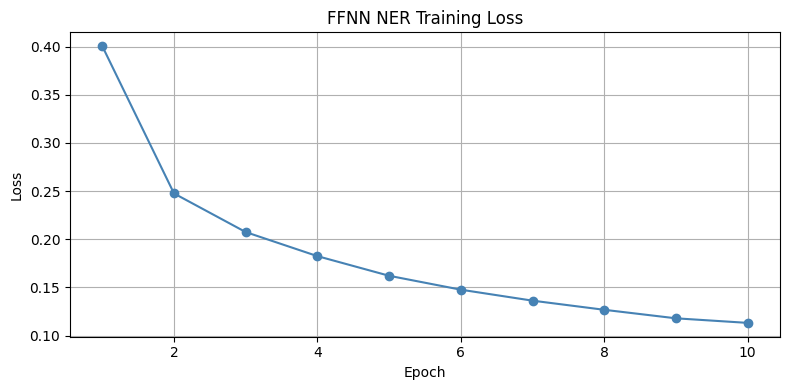

In [9]:

ner_model = FFNN_NER(
    input_dim   = 500,     # embedding size
    hidden_dim  = 256,
    num_classes = label_nums, # 9
    dropout     = 0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ner_model.parameters(), lr=1e-3)

best_val_f1       = 0
best_weights      = None
loss_history      = []

last_train_preds, last_train_labels = [], []
last_val_preds,   last_val_labels   = [], []

for epoch in range(10):

    # ── Training ──────────────────────────────────────────────
    ner_model.train()
    total_loss   = 0
    train_preds  = []
    train_labels = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = ner_model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        train_preds.extend(preds.argmax(dim=1).cpu().numpy())
        train_labels.extend(yb.cpu().numpy())

    # ── Validation ────────────────────────────────────────────
    ner_model.eval()
    val_preds, val_labels = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            p  = ner_model(xb).argmax(dim=1).cpu().numpy()
            val_preds.extend(p)
            val_labels.extend(yb.numpy())

    # ── Metrics ───────────────────────────────────────────────
    avg_loss  = total_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    val_acc   = accuracy_score(val_labels,   val_preds)
    val_f1    = f1_score(val_labels, val_preds, average="macro", zero_division=0)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1       = val_f1
        best_weights      = {k: v.clone() for k, v in ner_model.state_dict().items()}  

    # Save last epoch preds for final table
    last_train_preds,  last_train_labels = train_preds, train_labels
    last_val_preds,    last_val_labels   = val_preds,   val_labels


# Restore best weights
ner_model.load_state_dict(best_weights)
print(f"\nBest Val F1: {best_val_f1:.4f}")

# Plot loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o', color='steelblue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FFNN NER Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Step 8 — Evaluate on Test Set

We now run the best saved model on the held-out **test set** — data the model has never seen at all during training or hyperparameter tuning.

We report four metrics:

| Metric | What it measures |
|---|---|
| **Accuracy** | % of tokens correctly labelled overall |
| **Precision** | Of all tokens predicted as entity X, how many actually are X |
| **Recall** | Of all actual entity X tokens, how many did we correctly find |
| **F1-Score** | Harmonic mean of precision and recall — the main metric |

We use **macro** averaging — compute the metric per class then take the unweighted mean. This treats all 9 tags equally, so performance on rare entity types matters as much as the dominant `O` tag.

In [10]:
ner_model.eval()

def get_metrics(loader):
    preds_list, labels_list = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb    = xb.to(device)
            preds = ner_model(xb).argmax(dim=1).cpu().numpy()
            preds_list.extend(preds)
            labels_list.extend(yb.numpy())

    acc  = accuracy_score (labels_list, preds_list)
    prec = precision_score(labels_list, preds_list, average="macro", zero_division=0)
    rec  = recall_score   (labels_list, preds_list, average="macro", zero_division=0)
    f1   = f1_score       (labels_list, preds_list, average="macro", zero_division=0)

    return acc, prec, rec, f1


train_acc, train_prec, train_rec, train_f1 = get_metrics(train_loader)
val_acc,   val_prec,   val_rec,   val_f1   = get_metrics(val_loader)
test_acc,  test_prec,  test_rec,  test_f1  = get_metrics(test_loader)

results = pd.DataFrame({
    "Metric"    : ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Train"     : [train_acc, train_prec, train_rec, train_f1],
    "Validation": [val_acc,   val_prec,   val_rec,   val_f1],
    "Test"      : [test_acc,  test_prec,  test_rec,  test_f1]
})

results

,Metric,Train,Validation,Test
0,Accuracy,0.979899,0.944317,0.926866
1,Precision,0.962250,0.853005,0.777511
2,Recall,0.886193,0.722299,0.666680
3,F1-Score,0.921969,0.778779,0.715993
